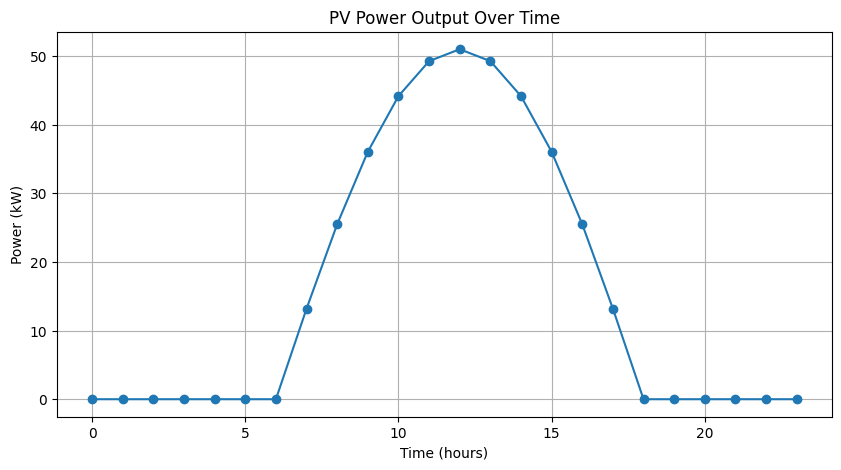

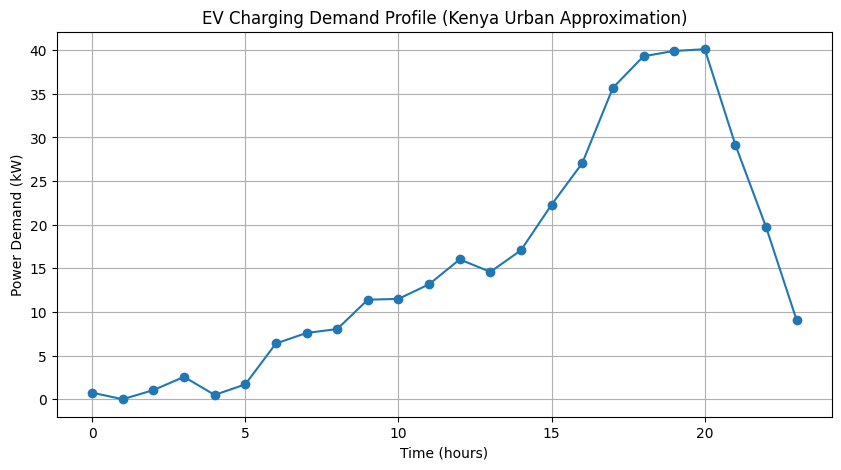

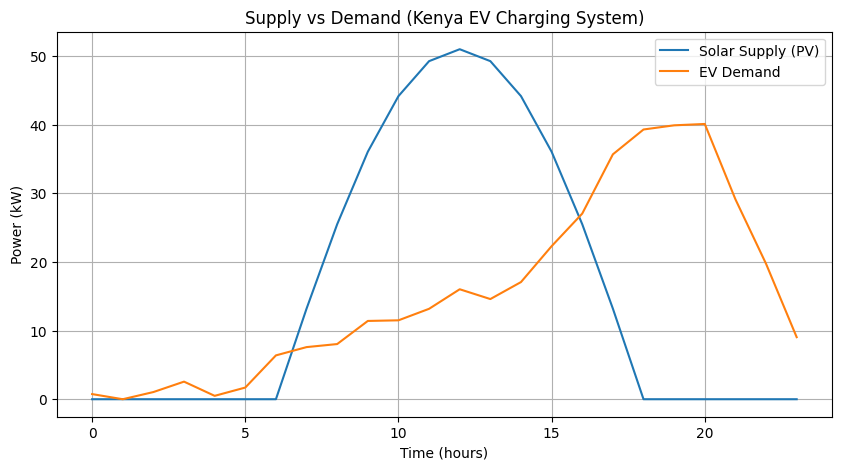

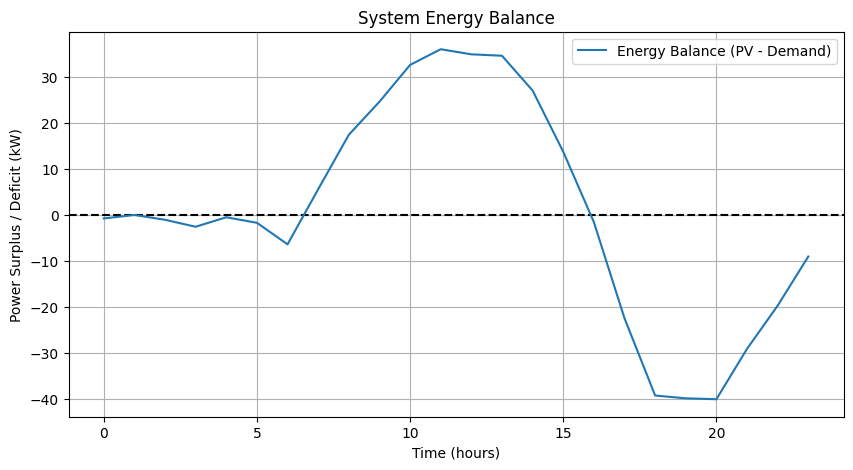

<Figure size 1000x500 with 0 Axes>

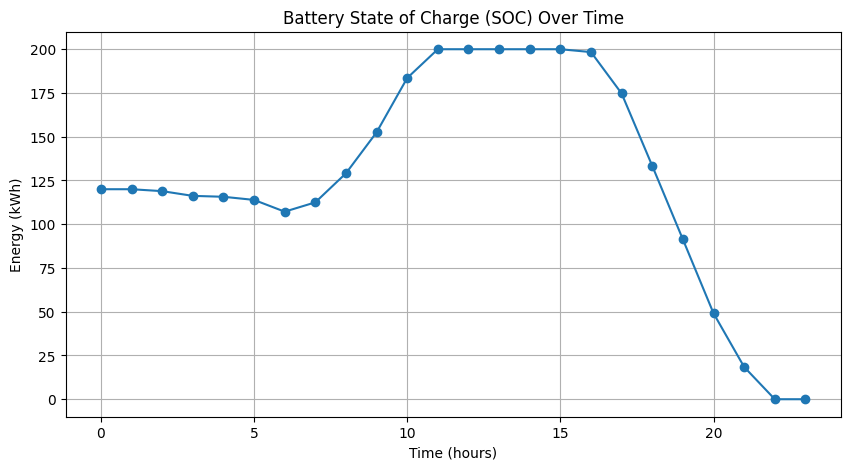

Total CO2 emissions (kg): 0.0


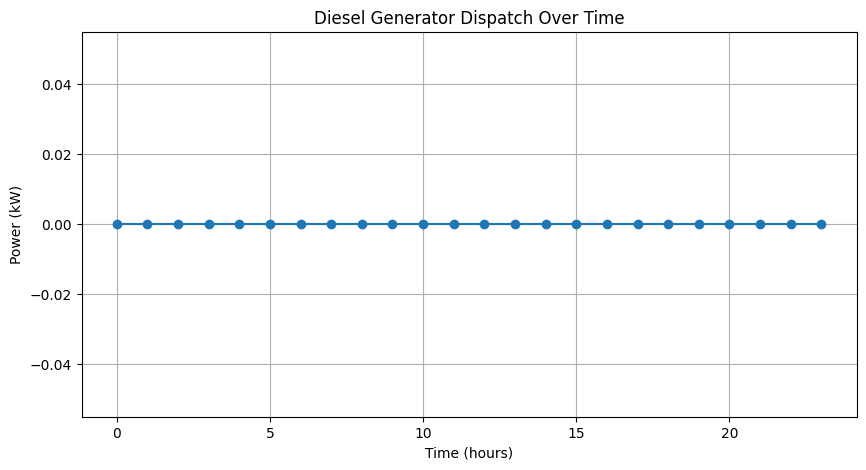

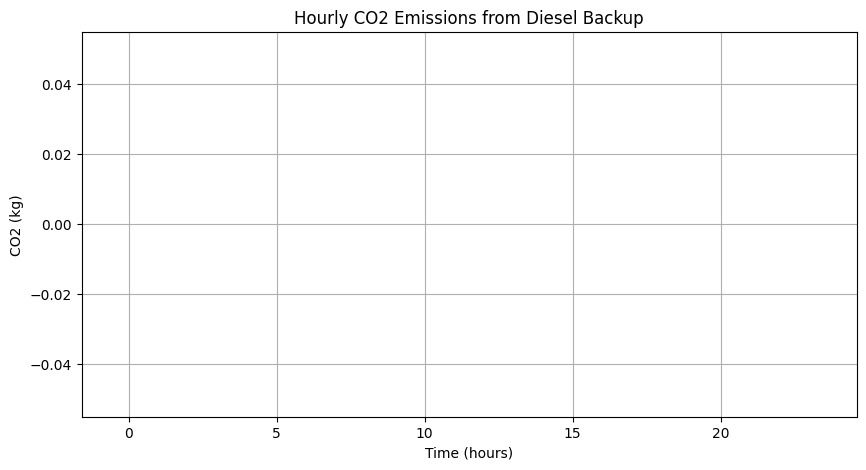

Total CO2 emissions (kg): 15.877460540317909
    Time (h)  PV Power (kW)  EV Demand (kW)  Battery SOC (kWh)  \
0          0   0.000000e+00        0.748003          30.000000   
1          1   0.000000e+00        0.000000          30.000000   
2          2   0.000000e+00        1.045136          28.899857   
3          3   0.000000e+00        2.562218          26.202785   
4          4   0.000000e+00        0.492082          25.684804   
5          5   0.000000e+00        1.700546          23.894756   
6          6   0.000000e+00        6.387454          17.171120   
7          7   1.319977e+01        7.594063          22.496543   
8          8   2.550000e+01        8.038572          39.084899   
9          9   3.606245e+01       11.406427          45.000000   
10        10   4.416730e+01       11.496839          45.000000   
11        11   4.926222e+01       13.174770          45.000000   
12        12   5.100000e+01       16.022656          45.000000   
13        13   4.926222e+01    

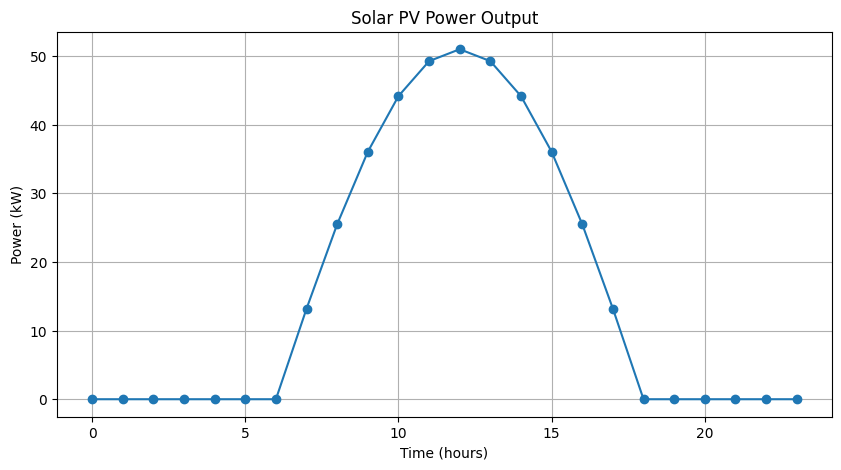

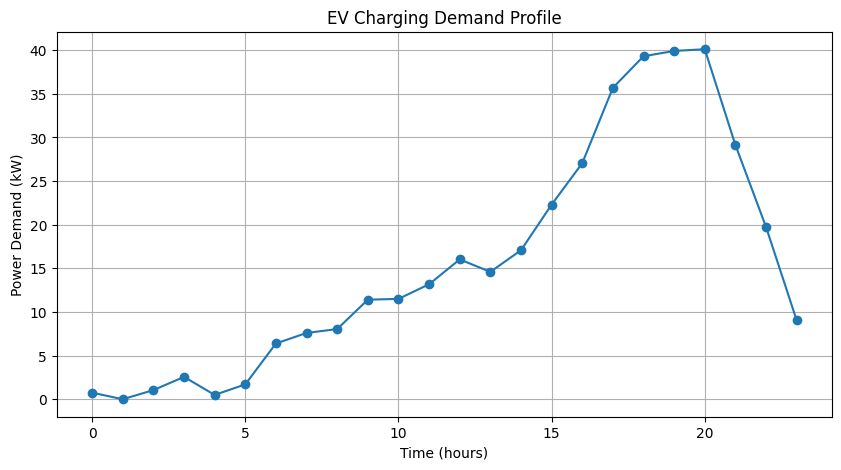

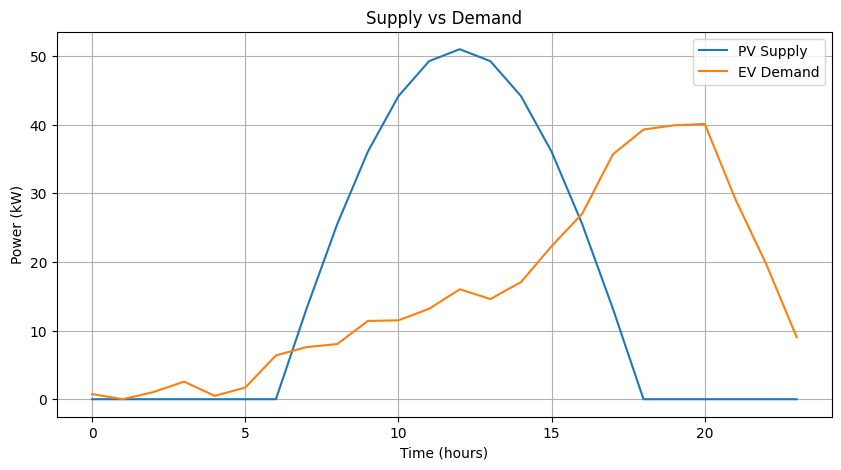

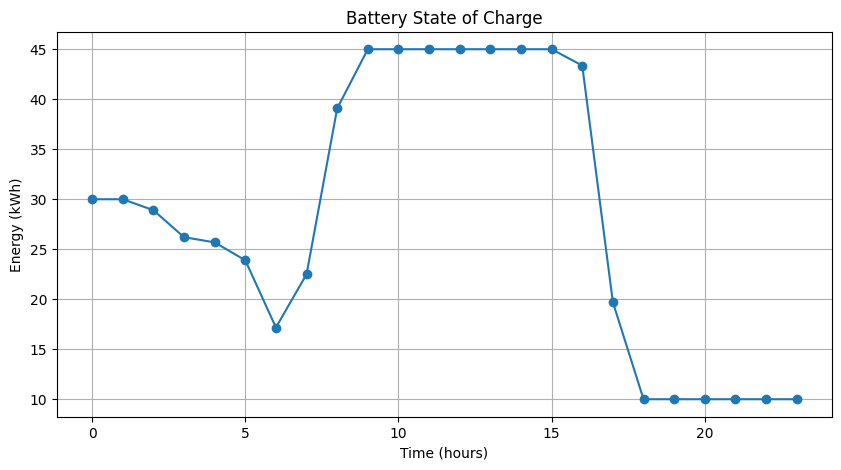

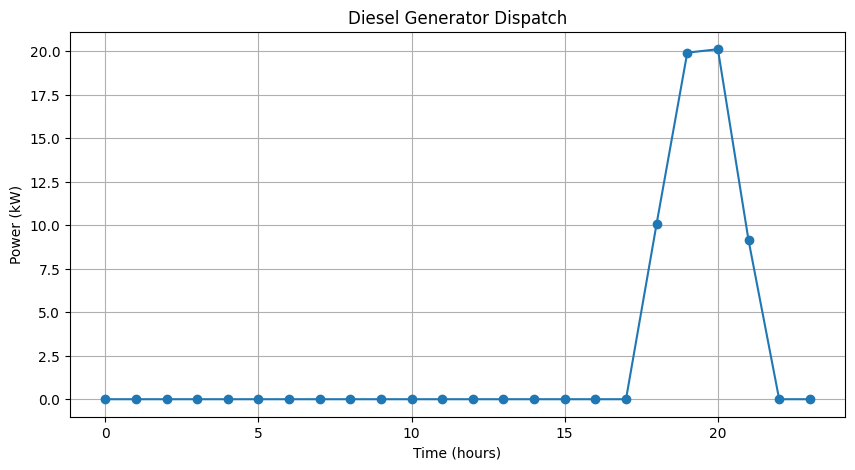

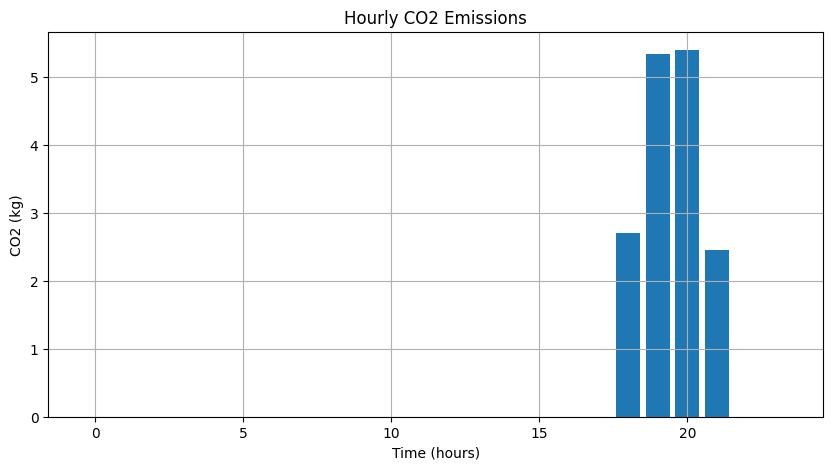

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================================
# TIME SETUP
# =========================================

t = np.arange(0, 24, 1)

# =========================================
# SOLAR IRRADIANCE MODEL
# =========================================

# Kenya-like irradiance profile
G = np.maximum(0, 1000 * np.sin((np.pi / 12) * (t - 6)))

# PV parameters
eta_pv = 0.20

A_panel = 1.7      # m² per panel
N_panel = 150      # number of panels

A = A_panel * N_panel

# PV power generation
P_pv = eta_pv * A * G

# Convert to kW
P_pv_kw = P_pv / 1000

# =========================================
# EV DEMAND MODEL
# =========================================

# EV charging demand profile
D_ev = (
    5 * np.exp(-0.5 * ((t - 8) / 2)**2) +
    15 * np.exp(-0.5 * ((t - 13) / 3)**2) +
    40 * np.exp(-0.5 * ((t - 19) / 2.5)**2)
)

# Add randomness
np.random.seed(42)
noise = np.random.normal(0, 1.5, size=len(t))

D_ev = np.maximum(0, D_ev + noise)

# =========================================
# SYSTEM BALANCE
# =========================================

balance = P_pv_kw - D_ev

# =========================================
# BATTERY PARAMETERS
# =========================================

E_cap = 50  # reduced slightly so diesel can activate realistically

SOC = np.zeros(len(t))
SOC[0] = 0.6 * E_cap

eta_ch = 0.95
eta_dis = 0.95

SOC_min = 0.2 * E_cap
SOC_max = 0.9 * E_cap

dt = 1

# =========================================
# GRID PARAMETERS
# =========================================

grid_limit = 20  # weak-grid constraint

# =========================================
# DIESEL PARAMETERS
# =========================================

diesel_capacity = 40  # kW max output

fuel_emission_factor = 2.68  # kg CO2/litre diesel
energy_per_litre = 10        # kWh/litre

# =========================================
# CONTROL VARIABLES
# =========================================

grid_supply = np.zeros(len(t))
diesel_supply = np.zeros(len(t))
battery_flow = np.zeros(len(t))
emissions = np.zeros(len(t))

# =========================================
# EMS SIMULATION LOOP
# =========================================

for i in range(1, len(t)):

    # previous battery state
    SOC[i] = SOC[i-1]

    # net power balance
    net = P_pv_kw[i] - D_ev[i]

    # =====================================
    # SURPLUS CONDITION
    # =====================================

    if net > 0:

        # battery charging
        charge = min(net, (SOC_max - SOC[i]) / eta_ch)

        SOC[i] += charge * eta_ch

        battery_flow[i] = charge

        grid_supply[i] = 0
        diesel_supply[i] = 0
        emissions[i] = 0

    # =====================================
    # DEFICIT CONDITION
    # =====================================

    else:

        deficit = -net

        # -----------------------------
        # BATTERY DISCHARGE
        # -----------------------------

        if SOC[i] > SOC_min:

            discharge = min(deficit / eta_dis, SOC[i] - SOC_min)

            SOC[i] -= discharge

            battery_flow[i] = -discharge

            deficit -= discharge * eta_dis

        # -----------------------------
        # GRID SUPPORT
        # -----------------------------

        if deficit > 0:

            grid_used = min(deficit, grid_limit)

            grid_supply[i] = grid_used

            deficit -= grid_used

        # -----------------------------
        # DIESEL BACKUP
        # -----------------------------

        if deficit > 0:

            diesel_used = min(deficit, diesel_capacity)

            diesel_supply[i] = diesel_used

            deficit -= diesel_used

            # fuel consumption
            fuel_used = diesel_used / energy_per_litre

            # CO2 emissions
            emissions[i] = fuel_used * fuel_emission_factor

        else:

            diesel_supply[i] = 0
            emissions[i] = 0

    # enforce SOC limits
    SOC[i] = np.clip(SOC[i], 0, E_cap)

# =========================================
# TOTAL EMISSIONS
# =========================================

total_emissions = np.sum(emissions)

print("Total CO2 emissions (kg):", total_emissions)

# =========================================
# RESULTS DATAFRAME
# =========================================

df = pd.DataFrame({
    "Time (h)": t,
    "PV Power (kW)": P_pv_kw,
    "EV Demand (kW)": D_ev,
    "Battery SOC (kWh)": SOC,
    "Grid Supply (kW)": grid_supply,
    "Diesel Supply (kW)": diesel_supply,
    "CO2 Emissions (kg)": emissions
})

print(df)

# =========================================
# PLOT 1 — PV GENERATION
# =========================================

plt.figure(figsize=(10,5))
plt.plot(t, P_pv_kw, marker='o')

plt.title("Solar PV Power Output")
plt.xlabel("Time (hours)")
plt.ylabel("Power (kW)")
plt.grid(True)

plt.show()

# =========================================
# PLOT 2 — EV DEMAND
# =========================================

plt.figure(figsize=(10,5))
plt.plot(t, D_ev, marker='o')

plt.title("EV Charging Demand Profile")
plt.xlabel("Time (hours)")
plt.ylabel("Power Demand (kW)")
plt.grid(True)

plt.show()

# =========================================
# PLOT 3 — SUPPLY VS DEMAND
# =========================================

plt.figure(figsize=(10,5))

plt.plot(t, P_pv_kw, label="PV Supply")
plt.plot(t, D_ev, label="EV Demand")

plt.title("Supply vs Demand")
plt.xlabel("Time (hours)")
plt.ylabel("Power (kW)")
plt.grid(True)
plt.legend()

plt.show()

# =========================================
# PLOT 4 — BATTERY SOC
# =========================================

plt.figure(figsize=(10,5))
plt.plot(t, SOC, marker='o')

plt.title("Battery State of Charge")
plt.xlabel("Time (hours)")
plt.ylabel("Energy (kWh)")
plt.grid(True)

plt.show()

# =========================================
# PLOT 5 — DIESEL DISPATCH
# =========================================

plt.figure(figsize=(10,5))
plt.plot(t, diesel_supply, marker='o')

plt.title("Diesel Generator Dispatch")
plt.xlabel("Time (hours)")
plt.ylabel("Power (kW)")
plt.grid(True)

plt.show()

# =========================================
# PLOT 6 — EMISSIONS
# =========================================

plt.figure(figsize=(10,5))
plt.bar(t, emissions)

plt.title("Hourly CO2 Emissions")
plt.xlabel("Time (hours)")
plt.ylabel("CO2 (kg)")
plt.grid(True)

plt.show()